# Ноутбук 02: Классификация русских рецензий на фильмы

- вместо английского IMDB взят русскоязычный датасет blinoff/kinopoisk;
- вместо бинарной классификации сделана трёхклассовая: NEGATIVE / NEUTRAL / POSITIVE;
- добавлена фильтрация данных;
- показаны примеры по классам;
- добавлена статистика датасета и анализ длины текстов;
- токенизация показана уже на русском примере;
- собрана сбалансированная выборка для тестирования;
- считаются accuracy, macro F1, weighted F1, classification report, confusion matrix;


In [1]:
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset, concatenate_datasets
from transformers import pipeline, AutoTokenizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix



c:\anacon\envs\nlp_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Шаг 1: Загрузка и подготовка русского датасета

In [2]:
raw_dataset = load_dataset('blinoff/kinopoisk', split='train')

label_map = {'Bad': 'NEGATIVE', 'Neutral': 'NEUTRAL', 'Good': 'POSITIVE'}

filtered_dataset = raw_dataset.filter(
    lambda x: isinstance(x['content'], str) and len(x['content'].strip()) > 40 and x['grade3'] in label_map
)

print('Размер исходного датасета:', len(raw_dataset))
print('Размер после фильтрации:', len(filtered_dataset))
print('Доступные поля:', filtered_dataset.column_names)


Размер исходного датасета: 36591
Размер после фильтрации: 36590
Доступные поля: ['part', 'movie_name', 'review_id', 'author', 'date', 'title', 'grade3', 'grade10', 'content']


In [3]:
def get_example(ds, grade3_label):
    item = ds.filter(lambda x: x['grade3'] == grade3_label).select(range(1))[0]
    return item

pos_example = get_example(filtered_dataset, 'Good')
neu_example = get_example(filtered_dataset, 'Neutral')
neg_example = get_example(filtered_dataset, 'Bad')

print('=== Позитивная рецензия (Good -> POSITIVE) ===')
print(pos_example['content'][:400], '...')
print()

print('=== Нейтральная рецензия (Neutral -> NEUTRAL) ===')
print(neu_example['content'][:400], '...')
print()

print('=== Негативная рецензия (Bad -> NEGATIVE) ===')
print(neg_example['content'][:400], '...')


=== Позитивная рецензия (Good -> POSITIVE) ===

"Блеф» — одна из моих самых любимых комедий.

Этот фильм я наверно смотрел раз сто, нет я конечно блефую, я видел его куда больше. Не могу не выразить своё восхищение главными действующими лицами этого фильма. Начну с Адриано Челентано для которого как я считаю это лучшая роль в кино. Великолепный актёр, неплохой певец, странно что на его родине в Италии его песни мало кто слушает. Ну я думаю что ...

=== Нейтральная рецензия (Neutral -> NEUTRAL) ===

- как пела Земфира, скорее всего, по совершенно другому поводу.

А вот и еще один «фильм с Челентаной», широко известный и всенародно любимый на территории бывшего СССР. По мне, так он получше более позднего «Укрощения строптивого» — в нем поменьше безыскусных домогательств и хамства.

Жанр фильма — «сентиментальная гангстерская байка», изложенная в виде комедии. Потенциал у жанра небольшой, но е ...

=== Негативная рецензия (Bad -> NEGATIVE) ===

Как же уныло… Я вынужден констатировать, что

Распределение классов:


,class,count,ratio
2,NEGATIVE,4750,0.129817
1,NEUTRAL,4576,0.125061
0,POSITIVE,27264,0.745122


Длина рецензий (первые 2000):
  Средняя: 269 слов
  Медиана: 229 слов
  Максимум: 1812 слов


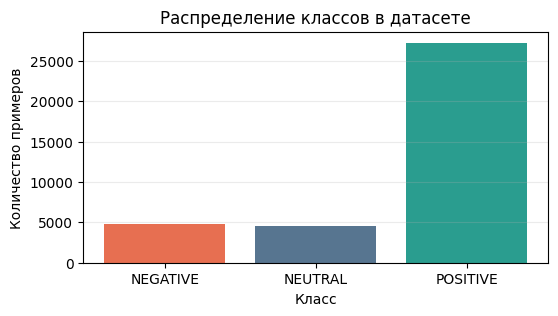

In [4]:
raw_counts = Counter(filtered_dataset['grade3'])
class_counts = {label_map[k]: v for k, v in raw_counts.items()}

stats_df = pd.DataFrame(
    [{'class': k, 'count': v, 'ratio': v / len(filtered_dataset)} for k, v in class_counts.items()]
).sort_values('class')

print('Распределение классов:')
display(stats_df)

lengths = [len(text.split()) for text in filtered_dataset['content'][:2000]]
print('Длина рецензий (первые 2000):')
print(f'  Средняя: {np.mean(lengths):.0f} слов')
print(f'  Медиана: {np.median(lengths):.0f} слов')
print(f'  Максимум: {max(lengths)} слов')

plt.figure(figsize=(6, 3))
plt.bar(stats_df['class'], stats_df['count'], color=['#e76f51', '#577590', '#2a9d8f'])
plt.title('Распределение классов в датасете')
plt.xlabel('Класс')
plt.ylabel('Количество примеров')
plt.grid(axis='y', alpha=0.25)
plt.show()


## Шаг 2: Понимаем токенизацию на русском тексте

In [5]:
model_name = 'blanchefort/rubert-base-cased-sentiment-rurewiews'
tokenizer = AutoTokenizer.from_pretrained(model_name)

text = 'Фильм визуально красивый, но сюжет местами провисает и теряет темп.'

tokens = tokenizer.tokenize(text)
encoded = tokenizer.encode(text)
decoded = tokenizer.decode(encoded)

print(f'Исходный текст: "{text}"')
print()
print(f'Токены ({len(tokens)} шт.): {tokens}')
print()
print(f'IDs:            {encoded}')
print()
print(f'Назад:          "{decoded}"')
print()
print('Обратите внимание на subword-токены и специальные токены [CLS]/[SEP].')


Исходный текст: "Фильм визуально красивый, но сюжет местами провисает и теряет темп."

Токены (13 шт.): ['Фильм', 'визуально', 'красивый', ',', 'но', 'сюжет', 'местами', 'прови', '##сает', 'и', 'теряет', 'темп', '.']

IDs:            [101, 16237, 32782, 6475, 128, 876, 5279, 13224, 15840, 36376, 322, 19211, 10828, 132, 102]

Назад:          "[CLS] Фильм визуально красивый, но сюжет местами провисает и теряет темп. [SEP]"

Обратите внимание на subword-токены и специальные токены [CLS]/[SEP].


## Шаг 3: Inference на сбалансированной выборке

In [6]:
classifier = pipeline(
    task='text-classification',
    model=model_name,
    device=0 if torch.cuda.is_available() else -1,
)

per_class = 120
parts = []
for src_label in ['Bad', 'Neutral', 'Good']:
    subset = filtered_dataset.filter(lambda x: x['grade3'] == src_label)
    take_n = min(per_class, len(subset))
    parts.append(subset.select(range(take_n)))

balanced_sample = concatenate_datasets(parts).shuffle(seed=42)

sample_counts = Counter([label_map[x] for x in balanced_sample['grade3']])
print(f'Размер тестовой выборки: {len(balanced_sample)}')
print('Распределение классов в тесте:', dict(sample_counts))


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 4714.23it/s]
BertForSequenceClassification LOAD REPORT from: blanchefort/rubert-base-cased-sentiment-rurewiews
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Размер тестовой выборки: 360
Распределение классов в тесте: {'POSITIVE': 120, 'NEGATIVE': 120, 'NEUTRAL': 120}


In [7]:
texts = [str(t) for t in balanced_sample['content']]
true_labels = [label_map[x] for x in balanced_sample['grade3']]

predictions_raw = classifier(texts, batch_size=8, truncation=True, max_length=512)
pred_labels = [r['label'] for r in predictions_raw]
pred_scores = [float(r['score']) for r in predictions_raw]

print('Inference завершен!')
print('Первые 5 предсказаний:', pred_labels[:5])
print('Первые 5 реальных:    ', true_labels[:5])


Inference завершен!
Первые 5 предсказаний: ['POSITIVE', 'POSITIVE', 'POSITIVE', 'POSITIVE', 'NEUTRAL']
Первые 5 реальных:     ['POSITIVE', 'NEGATIVE', 'NEUTRAL', 'NEUTRAL', 'POSITIVE']


## Шаг 4: Метрики качества

In [8]:
labels_order = ['NEGATIVE', 'NEUTRAL', 'POSITIVE']

accuracy = accuracy_score(true_labels, pred_labels)
macro_f1 = f1_score(true_labels, pred_labels, average='macro')
weighted_f1 = f1_score(true_labels, pred_labels, average='weighted')

print(f'Accuracy:    {accuracy:.1%}')
print(f'Macro F1:    {macro_f1:.3f}')
print(f'Weighted F1: {weighted_f1:.3f}')
print()

print('Детальный отчет по классам:')
print(classification_report(true_labels, pred_labels, labels=labels_order))


Accuracy:    48.6%
Macro F1:    0.478
Weighted F1: 0.478

Детальный отчет по классам:
              precision    recall  f1-score   support

    NEGATIVE       0.47      0.30      0.37       120
     NEUTRAL       0.41      0.53      0.46       120
    POSITIVE       0.58      0.63      0.61       120

    accuracy                           0.49       360
   macro avg       0.49      0.49      0.48       360
weighted avg       0.49      0.49      0.48       360



Матрица ошибок:


,PRED_NEGATIVE,PRED_NEUTRAL,PRED_POSITIVE
TRUE_NEGATIVE,36,67,17
TRUE_NEUTRAL,20,63,37
TRUE_POSITIVE,21,23,76


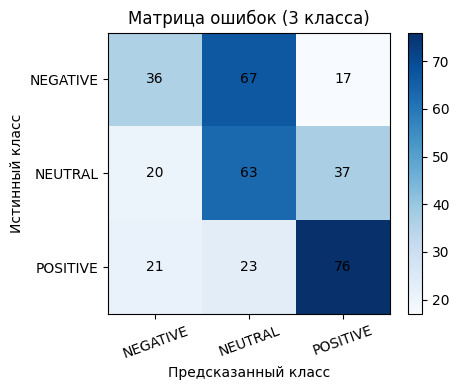

In [9]:
cm = confusion_matrix(true_labels, pred_labels, labels=labels_order)
cm_df = pd.DataFrame(cm, index=[f'TRUE_{x}' for x in labels_order], columns=[f'PRED_{x}' for x in labels_order])

print('Матрица ошибок:')
display(cm_df)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap='Blues')
plt.title('Матрица ошибок (3 класса)')
plt.xticks(range(len(labels_order)), labels_order, rotation=20)
plt.yticks(range(len(labels_order)), labels_order)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()


## Шаг 5: Анализ ошибок и ручные примеры

In [10]:
errors = [
    {
        'text': texts[i],
        'true': true_labels[i],
        'pred': pred_labels[i],
        'score': pred_scores[i],
    }
    for i in range(len(texts))
    if pred_labels[i] != true_labels[i]
]

print(f'Всего ошибок: {len(errors)}')
print()

for i, err in enumerate(errors[:3], 1):
    print(f'--- Ошибка {i} ---')
    print(f'Истинный класс: {err["true"]}')
    print(f'Предсказание:   {err["pred"]} (уверенность: {err["score"]:.1%})')
    print(f'Текст: {err["text"][:260]}...')
    print()


Всего ошибок: 185

--- Ошибка 1 ---
Истинный класс: NEGATIVE
Предсказание:   POSITIVE (уверенность: 71.5%)
Текст: 
Фильм не произвел должного впечатления. Честно говоря, я даже не совсем поняла, почему яильм назван «Апокалипсис» — особого апокалипсиса не наблюдалось. Интересно было услышать древний язык, актеры были на высоте, но чего — то в этом фильме не хватает. 

4 из...

--- Ошибка 2 ---
Истинный класс: NEUTRAL
Предсказание:   POSITIVE (уверенность: 76.5%)
Текст: 
Добавлю немного рассуждений к бесчисленным отзывам о мультфильме «Как приручить дракона». 

В этой картине, безусловно, есть много плюсов, которые невозможно не отметить. 

Прежде всего удивительная прорисовка пейзажей. Действительно захватывает дух. 

Замеча...

--- Ошибка 3 ---
Истинный класс: NEUTRAL
Предсказание:   POSITIVE (уверенность: 87.2%)
Текст: 
Веселый, зажигательный, интересный мультфильм, на котором можно действительно отдохнуть. Красивая картинка, замечательные поющие персонажи, прелестные животные, трогат

In [11]:
my_texts = [
    'Фильм оказался удивительно глубоким и трогательным, рекомендую к просмотру.',
    'Снято дешево, актеры переигрывают, смотреть невозможно.',
    'Есть интересные идеи, но реализация неровная: местами скучно, местами увлекательно.',
]

results = classifier(my_texts, truncation=True, max_length=512)
for text, result in zip(my_texts, results):
    print(f'{result["label"]:9s} ({result["score"]:.1%}): "{text}"')


POSITIVE  (99.4%): "Фильм оказался удивительно глубоким и трогательным, рекомендую к просмотру."
NEGATIVE  (71.9%): "Снято дешево, актеры переигрывают, смотреть невозможно."
NEUTRAL   (89.1%): "Есть интересные идеи, но реализация неровная: местами скучно, местами увлекательно."
